# Spatial blocked validation: interpolation vs multi-output GP vs DRF

This notebook compares three methods on the same 74-location real CS2–IS2
transect using five **contiguous spatial folds**. Every prediction shown here is
out of fold: the corresponding spatial block was not used to fit that model.

Methods:

1. **Pointwise + linear interpolation:** algebraically invert training pairs to
   $H_i,H_s$, linearly interpolate the latent estimates, then reconstruct both
   freeboards with the physical matrix $H$.
2. **Multi-output GP:** train the latent $H_i,H_s$ likelihood on four blocks and
   predict the held-out block.
3. **Physics-informed DRF:** a two-output DRF predicts $H_i,H_s$ and is trained
   through the same observation layer $y=Hf$. It uses 300 epochs and a
   three-member ensemble.

Because independent $H_i/H_s$ truth is unavailable, formal comparison is based
only on held-out CS2 and IS2 freeboards. Differences between latent estimates
are diagnostic, not retrieval-error measurements.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

gp = np.genfromtxt(
    '../results/blocked_validation_gp_predictions.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
drf = np.genfromtxt(
    '../results/blocked_validation_drf_predictions.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)
drf_penalty = np.genfromtxt(
    '../results/blocked_validation_drf_predictions_penalty.csv', delimiter=',', names=True,
    dtype=None, encoding='utf-8'
)

assert np.array_equal(gp['row_id'], drf['row_id'])
assert np.array_equal(gp['fold'], drf['fold'])
assert np.allclose(gp['distance_km'], drf['distance_km'])

distance = np.asarray(gp['distance_km'], dtype=float)
fold = np.asarray(gp['fold'], dtype=int)
actual = np.column_stack([gp['actual_cs2_m'], gp['actual_is2_m']])
point_pred = np.column_stack([gp['point_pred_cs2_m'], gp['point_pred_is2_m']])
gp_pred = np.column_stack([gp['gp_pred_cs2_m'], gp['gp_pred_is2_m']])
drf_pred = np.column_stack([drf['drf_pred_cs2_m'], drf['drf_pred_is2_m']])
drf_penalty_pred = np.column_stack([
    drf_penalty['drf_pred_cs2_m'], drf_penalty['drf_pred_is2_m']
])

print('rows:', len(distance))
print('fold sizes:', {int(f): int((fold == f).sum()) for f in np.unique(fold)})


rows: 74
fold sizes: {0: 15, 1: 15, 2: 15, 3: 15, 4: 14}


## Overall held-out metrics


In [2]:
def metrics(y, pred):
    error = pred - y
    return {
        'RMSE': float(np.sqrt(np.mean(error**2))),
        'MAE': float(np.mean(np.abs(error))),
        'bias': float(np.mean(error)),
    }

methods = {'Point + linear': point_pred, 'Multi-output GP': gp_pred, 'DRF': drf_pred}
sensors = ['CS2', 'IS2']
summary = {}
for method, prediction in methods.items():
    summary[method] = {
        sensor: metrics(actual[:, j], prediction[:, j])
        for j, sensor in enumerate(sensors)
    }

for method, result in summary.items():
    print(method)
    for sensor in sensors:
        values = result[sensor]
        print(
            f"  {sensor}: RMSE={values['RMSE']:.4f} m, "
            f"MAE={values['MAE']:.4f} m, bias={values['bias']:.4f} m"
        )

print()
print('DRF positivity ablation (penalty only; not used as the main physical model)')
for j, sensor in enumerate(sensors):
    values = metrics(actual[:,j], drf_penalty_pred[:,j])
    print(f"  {sensor}: RMSE={values['RMSE']:.4f} m, MAE={values['MAE']:.4f} m")
print('  negative held-out snow predictions:', int((drf_penalty['drf_Hs_m'] < 0).sum()))


Point + linear
  CS2: RMSE=0.0628 m, MAE=0.0498 m, bias=-0.0155 m
  IS2: RMSE=0.1167 m, MAE=0.0859 m, bias=-0.0183 m
Multi-output GP
  CS2: RMSE=0.0733 m, MAE=0.0575 m, bias=-0.0456 m
  IS2: RMSE=0.1173 m, MAE=0.0975 m, bias=-0.0349 m
DRF
  CS2: RMSE=0.0905 m, MAE=0.0724 m, bias=-0.0165 m
  IS2: RMSE=0.1231 m, MAE=0.0939 m, bias=0.0302 m

DRF positivity ablation (penalty only; not used as the main physical model)
  CS2: RMSE=0.0930 m, MAE=0.0783 m
  IS2: RMSE=0.1091 m, MAE=0.0811 m
  negative held-out snow predictions: 7


## Held-out predictions along the transect


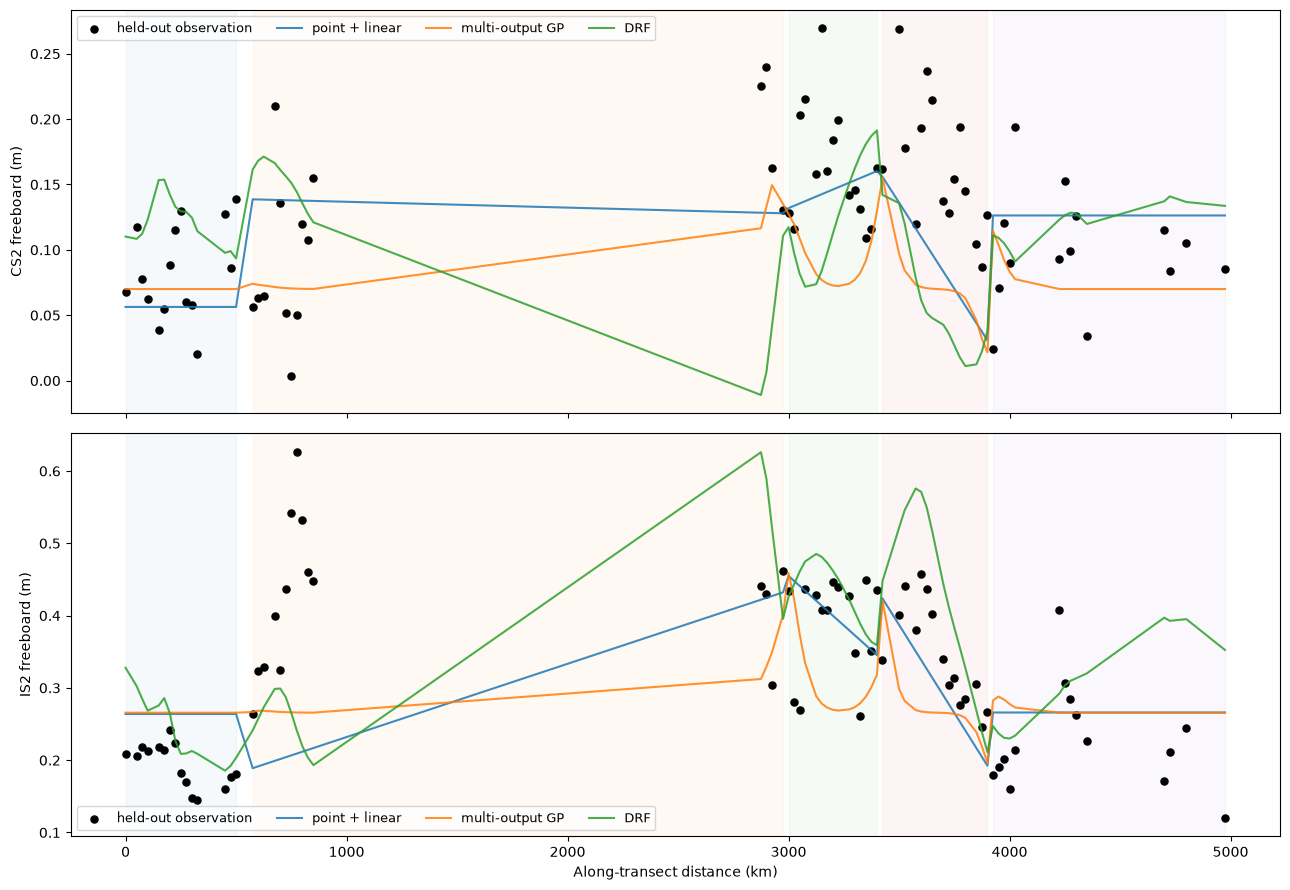

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for j, ax in enumerate(axs):
    for f in np.unique(fold):
        idx = np.where(fold == f)[0]
        ax.axvspan(distance[idx].min(), distance[idx].max(),
                   color=f'C{f}', alpha=0.045)
    ax.scatter(distance, actual[:,j], s=26, color='black', label='held-out observation')
    ax.plot(distance, point_pred[:,j], label='point + linear', alpha=0.85)
    ax.plot(distance, gp_pred[:,j], label='multi-output GP', alpha=0.85)
    ax.plot(distance, drf_pred[:,j], label='DRF', alpha=0.85)
    ax.set_ylabel(f'{sensors[j]} freeboard (m)')
    ax.legend(ncol=4, fontsize=9)
axs[-1].set_xlabel('Along-transect distance (km)')
plt.tight_layout()


## Error by spatial fold


In [4]:
for f in np.unique(fold):
    mask = fold == f
    print(f'Fold {f}: distance {distance[mask].min():.0f}–{distance[mask].max():.0f} km')
    for method, prediction in methods.items():
        cs2 = metrics(actual[mask,0], prediction[mask,0])['RMSE']
        is2 = metrics(actual[mask,1], prediction[mask,1])['RMSE']
        print(f'  {method:18s} CS2={cs2:.4f} m  IS2={is2:.4f} m')


Fold 0: distance 0–500 km
  Point + linear     CS2=0.0437 m  IS2=0.0759 m
  Multi-output GP    CS2=0.0370 m  IS2=0.0776 m
  DRF                CS2=0.0601 m  IS2=0.0591 m
Fold 1: distance 575–2975 km
  Point + linear     CS2=0.0734 m  IS2=0.2114 m
  Multi-output GP    CS2=0.0651 m  IS2=0.1707 m
  DRF                CS2=0.1168 m  IS2=0.2011 m
Fold 2: distance 3000–3400 km
  Point + linear     CS2=0.0493 m  IS2=0.0785 m
  Multi-output GP    CS2=0.0874 m  IS2=0.1239 m
  DRF                CS2=0.0836 m  IS2=0.0852 m
Fold 3: distance 3425–3900 km
  Point + linear     CS2=0.0860 m  IS2=0.0682 m
  Multi-output GP    CS2=0.1030 m  IS2=0.1029 m
  DRF                CS2=0.1170 m  IS2=0.1016 m
Fold 4: distance 3925–4975 km
  Point + linear     CS2=0.0497 m  IS2=0.0795 m
  Multi-output GP    CS2=0.0535 m  IS2=0.0851 m
  DRF                CS2=0.0513 m  IS2=0.1191 m


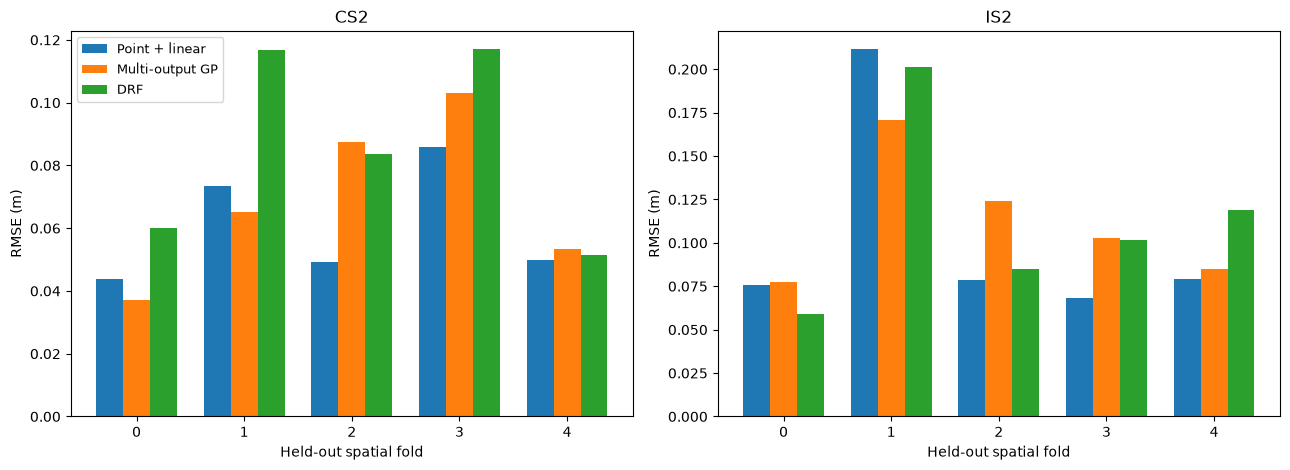

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)
width = 0.25
fold_values = np.unique(fold)
for j, ax in enumerate(axs):
    for offset, (method, prediction) in enumerate(methods.items()):
        rmses = [metrics(actual[fold == f,j], prediction[fold == f,j])['RMSE']
                 for f in fold_values]
        ax.bar(fold_values + (offset-1)*width, rmses, width=width, label=method)
    ax.set_title(sensors[j])
    ax.set_xlabel('Held-out spatial fold')
    ax.set_ylabel('RMSE (m)')
    ax.set_xticks(fold_values)
axs[0].legend(fontsize=9)
plt.tight_layout()


## Latent estimates: model disagreement, not accuracy

The following comparison shows what each model inferred for ice thickness and
snow depth at held-out locations. There is no independent latent truth in this
experiment, so agreement is not proof of correctness and disagreement cannot
identify which model is right.


point {'Hi_range': (0.9845377590227697, 2.6288529577684185), 'Hs_range': (0.03855636906405357, 0.24750422987470536), 'negative_Hi': 0, 'negative_Hs': 0}
GP {'Hi_range': (0.9533958460780919, 2.6233333099035594), 'Hs_range': (0.1290080910994214, 0.2540341021583456), 'negative_Hi': 0, 'negative_Hs': 0}
DRF {'Hi_range': (1.1018442, 2.9600897), 'Hs_range': (0.05527493, 0.48823252), 'negative_Hi': 0, 'negative_Hs': 0}


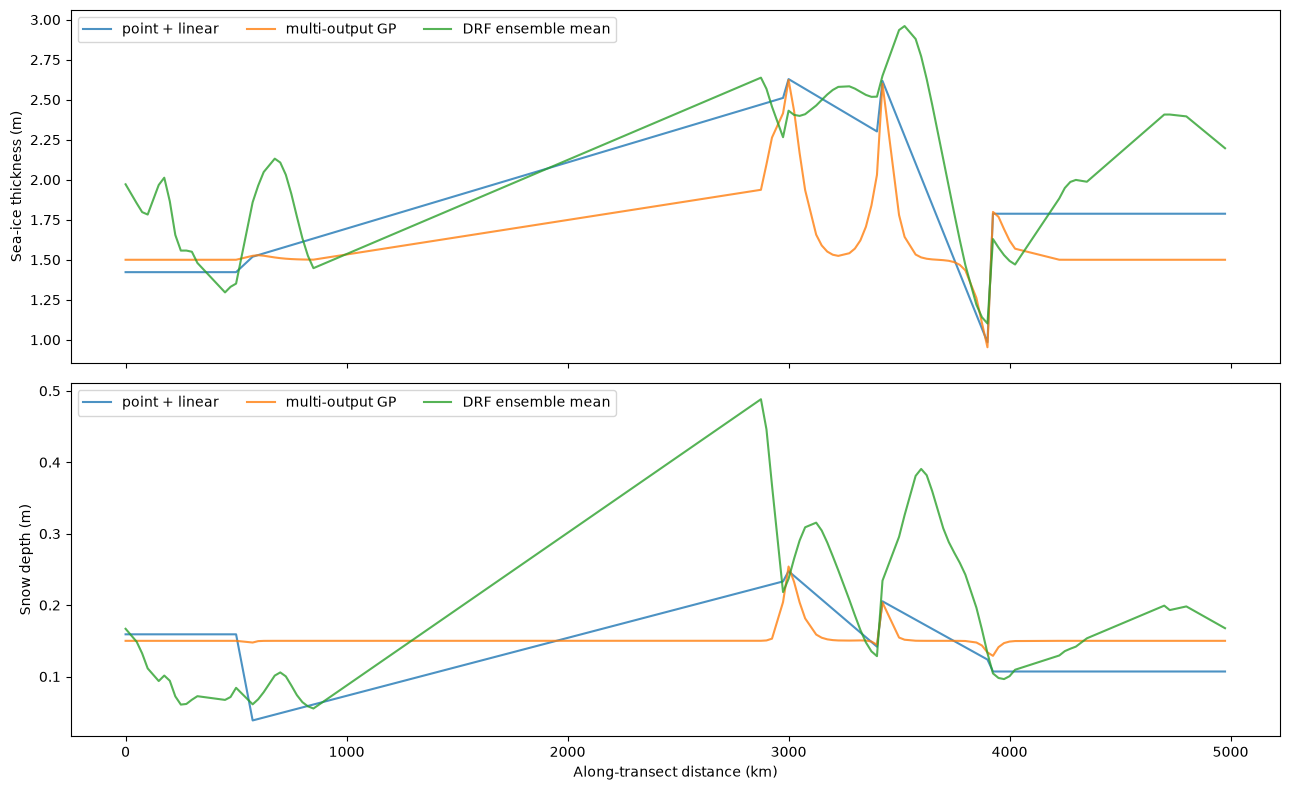

In [6]:
point_f = np.column_stack([gp['point_Hi_m'], gp['point_Hs_m']])
gp_f = np.column_stack([gp['gp_Hi_m'], gp['gp_Hs_m']])
drf_f = np.column_stack([drf['drf_Hi_m'], drf['drf_Hs_m']])

fig, axs = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
latent_names = ['Sea-ice thickness', 'Snow depth']
for j, ax in enumerate(axs):
    ax.plot(distance, point_f[:,j], label='point + linear', alpha=0.8)
    ax.plot(distance, gp_f[:,j], label='multi-output GP', alpha=0.8)
    ax.plot(distance, drf_f[:,j], label='DRF ensemble mean', alpha=0.8)
    ax.set_ylabel(latent_names[j] + ' (m)')
    ax.legend(ncol=3)
axs[-1].set_xlabel('Along-transect distance (km)')
plt.tight_layout()

for name, values in [('point', point_f), ('GP', gp_f), ('DRF', drf_f)]:
    print(name, {
        'Hi_range': (float(values[:,0].min()), float(values[:,0].max())),
        'Hs_range': (float(values[:,1].min()), float(values[:,1].max())),
        'negative_Hi': int((values[:,0] < 0).sum()),
        'negative_Hs': int((values[:,1] < 0).sum()),
    })


## Model-based uncertainty comparison


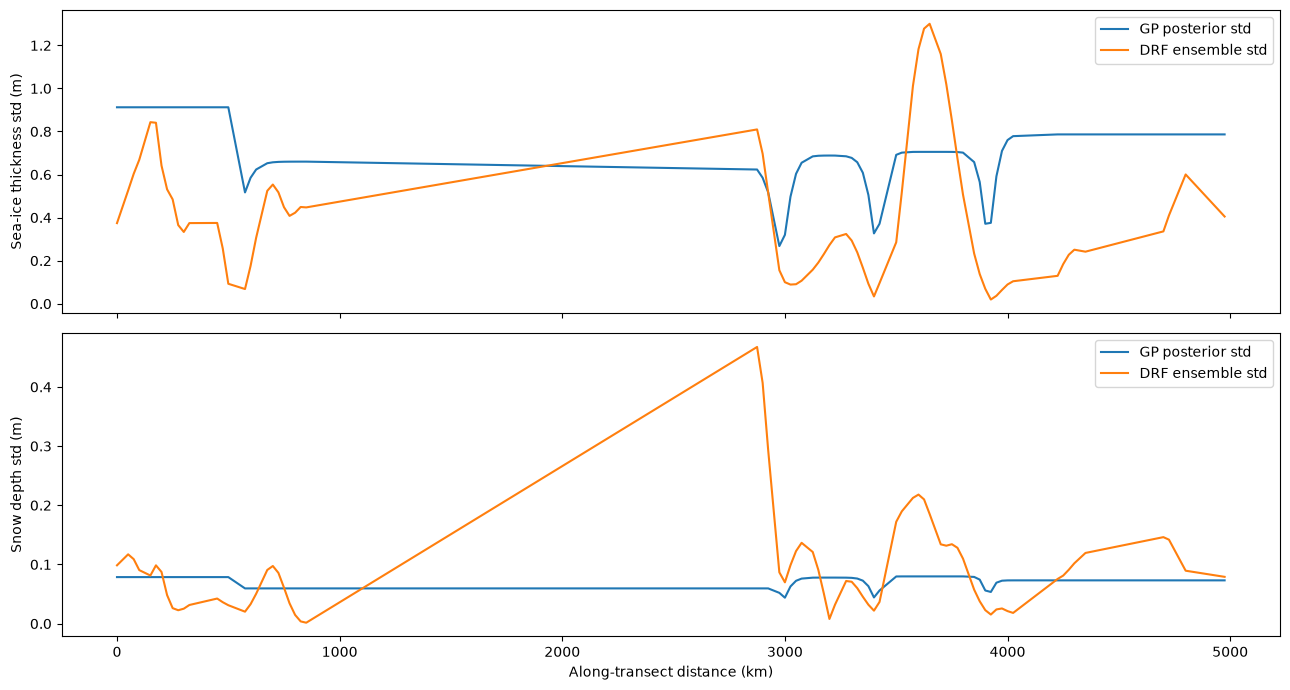

In [7]:
gp_std = np.column_stack([gp['gp_Hi_std_m'], gp['gp_Hs_std_m']])
drf_std = np.column_stack([
    drf['drf_Hi_ensemble_std_m'], drf['drf_Hs_ensemble_std_m']
])

fig, axs = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for j, ax in enumerate(axs):
    ax.plot(distance, gp_std[:,j], label='GP posterior std')
    ax.plot(distance, drf_std[:,j], label='DRF ensemble std')
    ax.set_ylabel(latent_names[j] + ' std (m)')
    ax.legend()
axs[-1].set_xlabel('Along-transect distance (km)')
plt.tight_layout()


## Evidence-based interpretation

- The physically valid pointwise-plus-linear baseline is strongest for both
  held-out freeboards in this experiment.
- The hard-positive DRF removes all negative latent predictions but does not
  beat the simple baseline or the GP.
- A penalty-only DRF ablation obtained a lower IS2 RMSE but produced seven
  negative held-out snow-depth estimates. It is therefore not accepted as the
  main physical result.
- The current unconstrained GP does not beat the simple baseline overall.
- One GP fold drove its optimized length scales to an effectively zero value,
  demonstrating hyperparameter degeneration during boundary extrapolation.
- DRF ensemble spread and GP posterior variance are different uncertainty
  constructions and are not directly calibrated by this experiment.

The next defensible method experiment is **pre-registered length-scale
sensitivity** (for example minimum scales of 25, 50 and 100 km) combined with
nested or training-only selection. Choosing the best constraint using these
same held-out folds would leak test information. Independent $H_i/H_s$
validation remains necessary before claiming retrieval accuracy.
